In [208]:
### in this task missing values *should be imputed* with the mean value of the column
### impute missing values only in columns required for solutions

In [210]:
import pandas as pd
import matplotlib.pyplot as plt

from statistics import NormalDist
import numpy as np
import math
import re


plt.rcParams.update({'font.size': 20, 'figure.figsize': (8, 4)})

#%matplotlib inline
#import matplotlib_inline
#matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import seaborn as sns
sns.set()

In [226]:
def is_symmetric_skewed_positive_or_skewed_negative(name_column):
    """
    Function to check skewness.
    """

    mean = df[name_column].mean()
    median = df[name_column].median()
    
    if mean > median:
        print("The distribution is positively skewed.")
    elif mean < median:
        print("The distribution is negatively skewed.")
    else:
        print("The distribution is symmetric.")

def fillna_with_mean(series):
    """
    Function to fill NaN values with the column mean.
     """
    
    mean_value = series.mean()
    return series.fillna(mean_value)


ounce_to_pounds = 1/16

def convert_weights(weight):
    """
    Function to convert weights from ounces to pounds.
    """
    
    if isinstance(weight, str):
        if 'pounds' in weight:
            return float(weight.split()[0])  # Extract and convert to float
        elif 'ounce' in weight:
            return float(weight.split()[0]) * ounce_to_pounds  # Convert ounces to pounds
    return None  # Handle cases where the format doesn't match or weight is not a string

def convert_dims(dims):
    """
    Function to convert dimensions to from the dataframe format to the product of dimensions.
    """
    
    if isinstance(dims, str):
        dim_list = re.findall(r'\d+(?:\.\d+)?', dims)
        return math.prod([float(dim) for dim in dim_list])
    else:
        return None

def confidence_interval(data, alpha):
    """
    Function to calculate the confidence interval
     """
    
    mean, std, n = data.mean(), data.std(), len(data)
    z = NormalDist().inv_cdf(1 - alpha / 2.0)
    left, right = mean - z * std / (n ** 0.5), mean + z * std / (n ** 0.5)
    return left, right

In [228]:
df = pd.read_csv("amazon_books_data.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 946 entries, 0 to 945
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   title        946 non-null    object 
 1   author       824 non-null    object 
 2   price        944 non-null    float64
 3   pages        934 non-null    float64
 4   avg_reviews  823 non-null    float64
 5   n_reviews    946 non-null    int64  
 6   dimensions   914 non-null    object 
 7   weight       943 non-null    object 
 8   language     943 non-null    object 
dtypes: float64(3), int64(1), object(5)
memory usage: 66.6+ KB


#### Question 1

In [231]:
### decide what data type each column is: numerical-discrete, numerical-continuous, categorical-nominal, categorical-ordinal
### consider only [price, pages, avg_reviews, n_reviews, language] for this analysis
### no need to add explanations, just the final answer

In [233]:
### price = numerical-continuous, pages = numerical-discrete, avg_reviews = numerical-continuous, n_reviews = numerical-continuous, language = categorical-nominal

"""
Creates a DataFrame that describes the types of different columns in a dataset.
Each column is labeled with its name and whether it is numerical (continuous/discrete) or categorical (nominal).
"""

column_types = {"column": ["price", "pages", "avg_reviews", "n_reviews", "language"],
                "data type": ["numerical-continuous", "numerical-discrete", "numerical-continuous", "numerical-discrete", "categorical-nominal"]}

res1 = pd.DataFrame(column_types)
res1

,column,data type
0,price,numerical-continuous
1,pages,numerical-discrete
2,avg_reviews,numerical-continuous
3,n_reviews,numerical-discrete
4,language,categorical-nominal


#### Question 2

In [236]:
### plot a histogram of books' number of pages using 50 bins
### decide if the distribution is symmetric, skewed positive or skewed negative
### use both the histogram and required computations for this decision

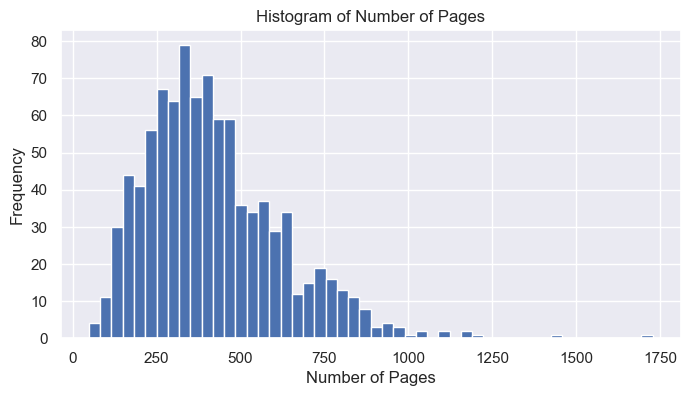

The distribution is positively skewed.


In [238]:
"""
Creates a histogram showing the distribution of the number of pages in the dataset.
It then checks whether the distribution is symmetric, positively skewed, or negatively skewed based on mean vs. median.
"""

plt.hist(df['pages'], bins=50)
plt.title('Histogram of Number of Pages')
plt.xlabel('Number of Pages')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

is_symmetric_skewed_positive_or_skewed_negative('pages')

#### Question 3

In [241]:
### inspect the 'weight' column carefully
### plot a histogram of books' weight using 50 bins
### decide if the distribution is symmetric, skewed positive or skewed negative
### use both the histogram and required computations for this decision

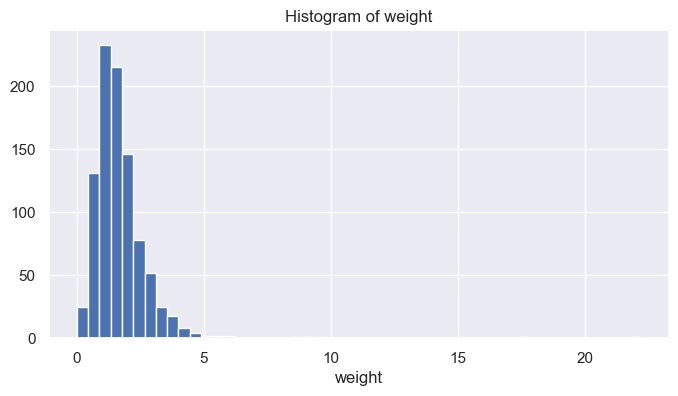

The distribution is positively skewed.


In [243]:
"""
Converts the 'weight' column to pounds, fills missing values with the mean, and plots a histogram of the converted weights.
It then determines if the distribution of weights is symmetric, positively skewed, or negatively skewed.
"""

df['weight'] = df['weight'].astype(str)
df['weights_in_pounds'] = df['weight'].apply(convert_weights)
df['weights_in_pounds'] = pd.to_numeric(df['weights_in_pounds'], errors='coerce')
df['weights_in_pounds'] = fillna_with_mean(df['weights_in_pounds'])

plt.hist(df['weights_in_pounds'], bins=50)
plt.title('Histogram of weight')
plt.xlabel('weight')
#lt.ylabel('Frequency')
plt.grid(True)
plt.show()

is_symmetric_skewed_positive_or_skewed_negative('weights_in_pounds')



#### Question 4

In [246]:
### compute Pearson's correlation between a book's volume (inferred by its dimensions) and price in the data
### (you can use the built-in Series.corr() function for that purpose)

In [248]:
"""
Code calculates the volume of each product based on its dimensions, fills missing values with the mean, and computes the Pearson correlation between volume and price.
It then prints the correlation value, showing how strongly volume and price are linearly related.
"""

df['volume'] = df['dimensions'].apply(convert_dims)
df['volume'] = fillna_with_mean(df['volume'])
correlation = df['volume'].corr(df['price'])

print(f"Pearson correlation between dimensions and price: {correlation:.3f}")

Pearson correlation between dimensions and price: 0.419


#### Question 5

In [251]:
### show a scatter plot of a book's volume (inferred by its dimensions) and price
### do the results fit the score you got in the previous cell? (no need to print answer to this question)

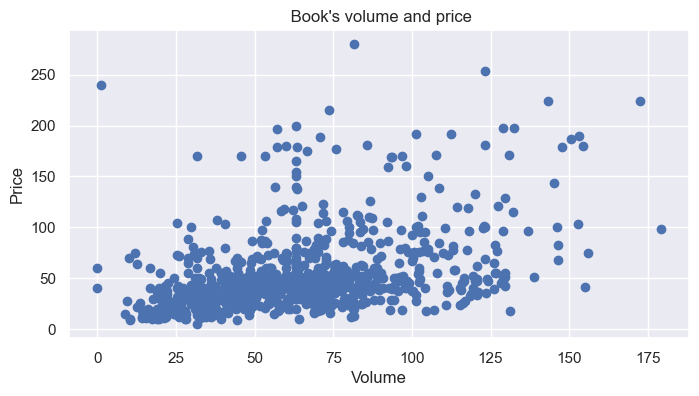

In [253]:
"""
Creates a scatter plot that visualizes the relationship between the volume of the books and their prices.
Based on the plot, it seems there is a weak positive correlation, which aligns with the Pearson correlation value you calculated earlier.
"""

plt.scatter(df['volume'], df['price'])
plt.title(' Book\'s volume and price')
plt.xlabel('Volume')
plt.ylabel('Price')
plt.show()

#It seems like there is a weak positive correlation so it matches the result we got

#### Question 6

In [256]:
### inspect book titles carefully: they can be roughly split by keyphrases:
### ['data science', 'data analytics', 'data engineering', 'machine learning', 'statistics', 
### 'deep learning', 'natural language processing']

### a book belongs to one of the above categories if its name contains the corresponding keyphrase
### display the number of books that fall into each category and their total, in the same table
### some books may not belong to any of the listed above categories
### category match should be case insensitive

In [284]:
"""
Checks if the 'title' column in the DataFrame contains any of the specified categories and creates new boolean columns for each category (True if the title contains the category, otherwise False).
It then counts how many books fall into each category and creates a summary DataFrame, showing the count for each category and the total count of all categories combined.
"""

categories = [
    'data science', 'data analytics', 'data engineering', 
    'machine learning', 'statistics', 'deep learning', 
    'natural language processing'
]

for category in categories:
    df[category] = df['title'].str.contains(category, case=False, na=False)
    
counts = {cat: df[cat].sum() for cat in categories}
total = sum(counts.values())

summary_df = pd.DataFrame.from_dict(counts, orient='index', columns=['Count'])
summary_df


,Count
data science,111
data analytics,28
data engineering,7
machine learning,179
statistics,128
deep learning,138
natural language processing,13


#### Question 7

In [287]:
### display the same result where the dataframe is sorted by the number of books, descending
### no need to display the total amount in this result - drop it

In [263]:
"""
The code sorts the summary_df DataFrame by the 'Count' column in descending order and stores the result in sorted_summary_df.
Then, it attempts to drop the row or column named 'Total' from sorted_summary_df.
"""

sorted_summary_df = summary_df.sort_values(by=['Count'], ascending=False)
sorted_summary_df.drop('Total')

,Count
machine learning,179
deep learning,138
statistics,128
data science,111
data analytics,28
natural language processing,13
data engineering,7


#### Question 8

In [266]:
### sample 10000 values from N~(50, 10)
### for this pirpose use https://numpy.org/doc/stable/reference/random/generated/numpy.random.normal.html

### what portion of the distribution is found in the range (42.5, 57.5)? -- calculate using z table
### (recall the NormalDist().cdf() function we used at the lecture)

### what portion of the distribution is found in the range (42.5, 57.5)? -- compute empirically using the sampled values
### report both values (calculated and empirical)

In [268]:
"""
The code calculates the probability of values between 42.5 and 57.5 using both the normal distribution's CDF (calculated) and an empirical method based on a sample (empirical). 
It then prints both probabilities for comparison.
"""
sample = np.random.normal(50, 10, 10000)

z1 = (57.5 - 50)/10
z2 = (42.5 - 50)/10

calculated = NormalDist().cdf(z1) - NormalDist().cdf(z2)

empirical = np.mean((sample >= 42.5) & (sample <= 57.5))

print(f"claculated: {calculated}, empirical: {empirical}")

claculated: 0.5467452952462635, empirical: 0.5526


#### Question 9

In [271]:
### compute confidence interval of 90% for the true population mean of a book price on Amazon
### report left and right boundaries

In [273]:
"""
The code calculates the 90% confidence interval for the 'price' column in the df DataFrame using the confidence_interval function.
It then prints the lower (left) and upper (right) bounds of the interval, rounded to two decimal places.
"""
left, right = confidence_interval(df['price'], 0.10)
print(f"left: {round(left, 2)}, right: {round(right, 2)}")

left: 50.15, right: 54.06


#### Question 10

In [276]:
### can one say with 85% confidence that the true population mean of a book price resides within the [49.0, 54.0] interval?
### show your computations, and print your answer: yes or no

In [278]:
"""
The code calculates the 85% confidence interval for the 'price' column in the df DataFrame using the confidence_interval function.
It then checks if the lower bound (left) is greater than or equal to 49, and the upper bound (right) is less than or equal to 54.
If both conditions are true, it prints 'yes'; otherwise, it prints 'no'.
"""

left, right = confidence_interval(df['price'], 0.15)
if(left >= 49 and right <= 54):
    print('yes')
else:
    print('no')
#yes 

yes
